In [1]:
import polars as pl
from utils import load_asap_dataset, get_score_range

asap = load_asap_dataset("./dataset")
asap

essay_set,essay_id,essay,score
i64,i64,str,i64
1,1,"""Dear local newspaper, I think …",8
1,2,"""Dear @CAPS1 @CAPS2, I believe …",9
1,3,"""Dear, @CAPS1 @CAPS2 @CAPS3 Mor…",7
1,4,"""Dear Local Newspaper, @CAPS1 I…",10
1,5,"""Dear @LOCATION1, I know having…",8
…,…,…,…
8,21626,""" In most stories mothers and d…",35
8,21628,""" I never understood the meanin…",32
8,21629,"""When you laugh, is @CAPS5 out …",40


In [3]:
import re
import json
from pathlib import Path

MODELS = [
    "gpt-4.1-2025-04-14",
    "gpt-5-2025-08-07",
    "gpt-5.4-mini-2026-03-17",
    "gpt-5.4-nano-2026-03-17",
]

results = {}
errors = {}

for MODEL in MODELS:
    results[MODEL] = []
    errors[MODEL] = []
    for target_prompt_id in range(1, 9):
        json_path = Path(f"out/{MODEL}/{target_prompt_id}/results.jsonl")
        with open(json_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    entry = json.loads(line.strip())
                except json.JSONDecodeError:
                    continue  # JSONとして読み込めない行はスキップ

                entry_id = entry.get("id")
                if MODEL in ["gpt-5.4-nano-2026-03-17"]:
                    text = entry.get("output_text", "")
                else:
                    text = entry.get("text", "")

                # <score>X</score> または Score: X （整数・小数対応、マイナスなし）
                match = re.search(r"<score>(\d+(?:\.\d+)?)</score>", text)
                if match:
                    score = float(match.group(1))
                    results[MODEL].append({"id": entry_id, "score": score})
                    continue

                match = re.search(r"Score:\s*(\d+(?:\.\d+)?)", text, re.IGNORECASE)
                if match:
                    score = float(match.group(1))
                    results[MODEL].append({"id": entry_id, "score": score})
                else:
                    errors[MODEL].append(
                        f"ID {entry_id} のスコアが不正な形式です: {text}"
                    )
    print(f"抽出結果[{MODEL}]: {len(results[MODEL])}件、エラー: {len(errors[MODEL])}件")

抽出結果[gpt-4.1-2025-04-14]: 12945件、エラー: 32件
抽出結果[gpt-5-2025-08-07]: 1295件、エラー: 0件
抽出結果[gpt-5.4-mini-2026-03-17]: 1293件、エラー: 2件
抽出結果[gpt-5.4-nano-2026-03-17]: 1295件、エラー: 0件


In [4]:
final_df = asap.__copy__()

for MODEL in MODELS:
    result = pl.DataFrame(
        results[MODEL], schema_overrides={"id": pl.Int64, "score": pl.Float64}
    )
    result = result.with_columns(pl.col("score").round(0).cast(pl.Int64))
    result = result.rename({"id": "essay_id", "score": f"pred_score_{MODEL}"})
    final_df = final_df.join(result, on="essay_id", how="left")

In [5]:
final_df

essay_set,essay_id,essay,score,pred_score_gpt-4.1-2025-04-14,pred_score_gpt-5-2025-08-07,pred_score_gpt-5.4-mini-2026-03-17,pred_score_gpt-5.4-nano-2026-03-17
i64,i64,str,i64,i64,i64,i64,i64
1,1,"""Dear local newspaper, I think …",8,6,null,null,null
1,2,"""Dear @CAPS1 @CAPS2, I believe …",9,6,null,null,null
1,3,"""Dear, @CAPS1 @CAPS2 @CAPS3 Mor…",7,6,4,null,null
1,4,"""Dear Local Newspaper, @CAPS1 I…",10,8,null,null,null
1,5,"""Dear @LOCATION1, I know having…",8,7,null,null,null
…,…,…,…,…,…,…,…
8,21626,""" In most stories mothers and d…",35,44,null,43,45
8,21628,""" I never understood the meanin…",32,38,32,null,null
8,21629,"""When you laugh, is @CAPS5 out …",40,44,null,null,null


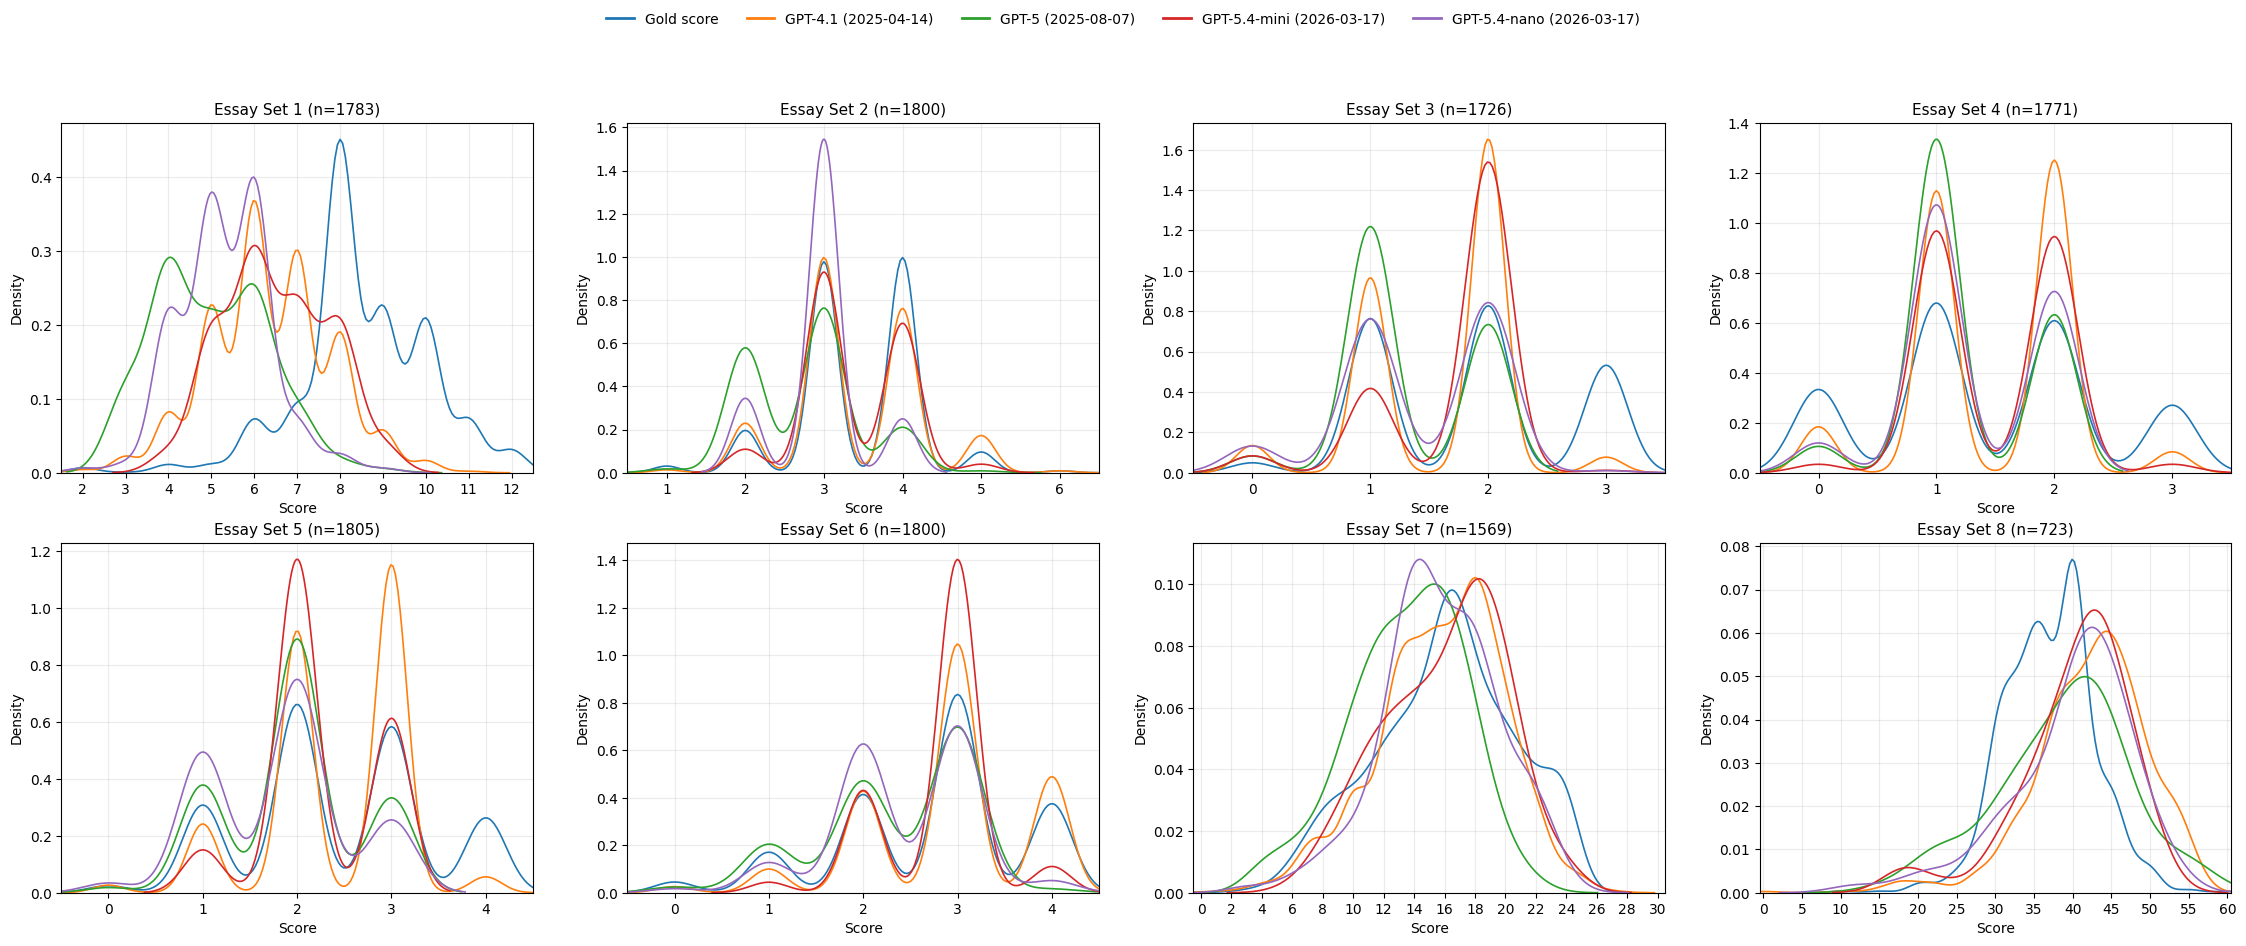

In [6]:
# 必要ライブラリ
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_asap_2x4_seaborn(
    df_pl: pl.DataFrame,
    dataset_name: str = "ASAP",
    sets=(1, 2, 3, 4, 5, 6, 7, 8),
    figsize=(28, 10),
    kde=False,
):
    """
    ASAP用: essay_setごとにスコアレンジを固定し、2x4サブプロットで分布を重ね描画（seaborn）。
    - df_pl: Polars DataFrame（必須列: 'essay_set','score'）
    - 予測列は存在すれば自動で重ねる。
    - kde=True で KDE も重ねられます。
    """
    # 使用カラムの決定
    candidate_cols = [
        "score",
        "pred_score_gpt-4.1-2025-04-14",
        "pred_score_gpt-5-2025-08-07",
        "pred_score_gpt-5.4-mini-2026-03-17",
        "pred_score_gpt-5.4-nano-2026-03-17",
    ]
    present_cols = []
    for c in candidate_cols:
        if (
            c in df_pl.columns
            and df_pl.select(pl.col(c).is_not_null().sum()).item() > 0
        ):
            present_cols.append(c)
    if "score" not in present_cols:
        raise ValueError("必須列 'score' が存在しないか、全て欠損です。")

    # 表示名（凡例）
    nice_name = {
        "score": "Gold score",
        "pred_score_gpt-4.1-2025-04-14": "GPT-4.1 (2025-04-14)",
        "pred_score_gpt-5-2025-08-07": "GPT-5 (2025-08-07)",
        "pred_score_gpt-5.4-mini-2026-03-17": "GPT-5.4-mini (2026-03-17)",
        "pred_score_gpt-5.4-nano-2026-03-17": "GPT-5.4-nano (2026-03-17)",
    }

    # seabornはpandas前提のため変換
    pdf = df_pl.select(["essay_set"] + present_cols).to_pandas()

    # Long化
    melted = pd.melt(
        pdf,
        id_vars=["essay_set"],
        value_vars=present_cols,
        var_name="source",
        value_name="score_value",
    )
    melted["score_value"] = pd.to_numeric(melted["score_value"], errors="coerce")
    melted = melted.dropna(subset=["score_value", "essay_set"])

    # 色と順序
    source_order = present_cols
    palette = sns.color_palette(n_colors=len(source_order))
    color_map = {s: palette[i] for i, s in enumerate(source_order)}

    # Figure: 2x4 固定
    nrows, ncols = 2, 4
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, sharex=False, sharey=False
    )
    axes = axes.flatten()

    # 動的 xtick ステップ（見やすさのため）
    def pick_tick_step(vmin, vmax):
        rng = vmax - vmin
        if rng <= 15:
            return 1
        if rng <= 30:
            return 2
        if rng <= 60:
            return 5
        return max(1, rng // 12)

    for idx, prompt_id in enumerate(sets):
        ax = axes[idx]
        if prompt_id not in melted["essay_set"].unique():
            # データがない場合は空白化
            ax.set_visible(False)
            continue

        sub = melted[melted["essay_set"] == prompt_id]

        # ASAPのスコア範囲を取得
        vmin, vmax = get_score_range(dataset_name, int(prompt_id))
        # 整数ビン（端を含むように+1）
        bins = np.arange(vmin - 0.5, vmax + 1.5, 1)

        # 各 source を個別に重ね描画（同一ビン・同一軸）
        for s in source_order:
            x = sub.loc[sub["source"] == s, "score_value"].dropna().values
            if x.size == 0:
                continue

            if kde:
                sns.kdeplot(x=x, ax=ax, lw=1.2, color=color_map[s], label=None)
            else:
                sns.histplot(
                    x=x,
                    bins=bins,
                    stat="density",
                    element="step",
                    fill=False,
                    ax=ax,
                    label=nice_name.get(s, s),
                    color=color_map[s],
                    common_norm=False,
                )

        # 軸・タイトル
        n_samples = sub.loc[sub["source"] == "score", "score_value"].shape[0]
        ax.set_title(f"Essay Set {prompt_id} (n={n_samples})", fontsize=11)
        ax.set_xlim(vmin - 0.5, vmax + 0.5)
        step = pick_tick_step(vmin, vmax)
        ax.set_xticks(np.arange(vmin, vmax + 1, step))
        ax.set_xlabel("Score", fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.grid(True, alpha=0.25)

    # 余った軸（8固定で埋めているが sets が8未満のケースをケア）
    for j in range(len(sets), nrows * ncols):
        axes[j].set_visible(False)

    # 共通凡例（上部）
    legend_elems = [
        Line2D([0], [0], color=color_map[s], lw=2, label=nice_name.get(s, s))
        for s in source_order
    ]
    fig.legend(
        handles=legend_elems, loc="upper center", ncols=len(source_order), frameon=False
    )
    # fig.suptitle("ASAP: Score Distributions by Essay Set (Gold vs GPT predictions)", fontsize=15, y=0.9)
    # plt.tight_layout()
    plt.show()


# 使い方例:
plot_asap_2x4_seaborn(df_pl=final_df, kde=True)

In [7]:
final_df

essay_set,essay_id,essay,score,pred_score_gpt-4.1-2025-04-14,pred_score_gpt-5-2025-08-07,pred_score_gpt-5.4-mini-2026-03-17,pred_score_gpt-5.4-nano-2026-03-17
i64,i64,str,i64,i64,i64,i64,i64
1,1,"""Dear local newspaper, I think …",8,6,null,null,null
1,2,"""Dear @CAPS1 @CAPS2, I believe …",9,6,null,null,null
1,3,"""Dear, @CAPS1 @CAPS2 @CAPS3 Mor…",7,6,4,null,null
1,4,"""Dear Local Newspaper, @CAPS1 I…",10,8,null,null,null
1,5,"""Dear @LOCATION1, I know having…",8,7,null,null,null
…,…,…,…,…,…,…,…
8,21626,""" In most stories mothers and d…",35,44,null,43,45
8,21628,""" I never understood the meanin…",32,38,32,null,null
8,21629,"""When you laugh, is @CAPS5 out …",40,44,null,null,null


In [9]:
from sklearn.metrics import cohen_kappa_score


def calc_qwk(df: pl.DataFrame) -> pl.DataFrame:
    data = {}
    for MODEL in MODELS:
        data[MODEL] = []
        for target_prompt_id in range(1, 9):
            minscore, maxscore = get_score_range("ASAP", target_prompt_id)
            tmp_df = df.filter(pl.col("essay_set") == target_prompt_id)
            tmp_df = tmp_df.drop_nulls(subset=[f"pred_score_{MODEL}", "score"])
            qwk = cohen_kappa_score(
                tmp_df[f"pred_score_{MODEL}"].to_numpy(),
                tmp_df["score"].to_numpy(),
                weights="quadratic",
                labels=list(range(minscore, maxscore + 1)),
            )
            data[MODEL].append(qwk)

    return pl.DataFrame(
        {
            "essay_set": list(range(1, 9)),
            MODELS[0]: data[MODELS[0]],
            MODELS[1]: data[MODELS[1]],
            MODELS[2]: data[MODELS[2]],
            MODELS[3]: data[MODELS[3]],
        }
    )


qwk_df = calc_qwk(final_df)
qwk_df = qwk_df.with_columns(
    [pl.col(col).round(3) for col in qwk_df.columns if col != "essay_set"]
)
qwk_df

essay_set,gpt-4.1-2025-04-14,gpt-5-2025-08-07,gpt-5.4-mini-2026-03-17,gpt-5.4-nano-2026-03-17
i64,f64,f64,f64,f64
1,0.239,0.109,0.181,0.073
2,0.636,0.389,0.551,0.334
3,0.492,0.385,0.445,0.309
4,0.702,0.608,0.589,0.548
5,0.663,0.621,0.542,0.522
6,0.704,0.647,0.546,0.557
7,0.642,0.617,0.43,0.415
8,0.513,0.679,0.284,0.308


In [10]:
qwk_df.mean()

essay_set,gpt-4.1-2025-04-14,gpt-5-2025-08-07,gpt-5.4-mini-2026-03-17,gpt-5.4-nano-2026-03-17
f64,f64,f64,f64,f64
4.5,0.573875,0.506875,0.446,0.38325
